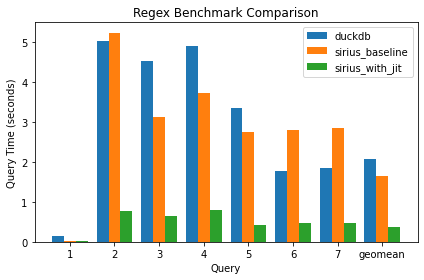

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gmean  # geometric mean

# CSV files mapped to implementation names
files = {
    "duckdb": "./duckDB/result.csv",
    "sirius_baseline": "./sirius_baseline/result.csv",
    "sirius_with_jit": "./with_jit/result.csv",
}

# Load all CSVs
dfs = {name: pd.read_csv(path) for name, path in files.items()}

# Assume all CSVs contain the same set of queries
queries = dfs[next(iter(dfs))]["query"].values
num_queries = len(queries)
num_impls = len(dfs)

# Compute geometric mean for each implementation
geom_means = {name: gmean(df["query_time_sec"].values) for name, df in dfs.items()}

# Extend queries list with a new label for geometric mean
queries_extended = list(queries) + ["geomean"]
num_groups = len(queries_extended)

# X positions
x = np.arange(num_groups)
bar_width = 0.8 / num_impls

plt.figure()

# Plot each implementation
for i, (name, df) in enumerate(dfs.items()):
    # Concatenate original query times with geometric mean
    times = np.append(df["query_time_sec"].values, geom_means[name])
    plt.bar(
        x + i * bar_width,
        times,
        bar_width,
        label=name,
    )

# Labels and formatting
plt.xlabel("Query")
plt.ylabel("Query Time (seconds)")
plt.title("Regex Benchmark Comparison")
plt.xticks(x + bar_width * (num_impls - 1) / 2, queries_extended)
plt.legend()

plt.tight_layout()

plt.savefig("benchmark.png", dpi=200)
plt.show()

In [7]:
plt.close()

In [9]:
print(geom_means)

{'duckdb': 1.3981322192483705, 'sirius_baseline': 0.9455510378945409, 'sirius_with_jit': 0.26314332294555554}


In [10]:
(geom_means['sirius_with_jit'] - geom_means['sirius_baseline'])/geom_means['sirius_baseline']

-0.7217037342251805

In [12]:
(geom_means['sirius_with_jit'] - geom_means['duckdb'])/geom_means['duckdb']

-0.8117893863521576

In [15]:
(geom_means['duckdb'] - geom_means['sirius_baseline'])/geom_means['sirius_baseline']

0.26475264812346616

In [16]:
(geom_means['sirius_baseline'] - geom_means['duckdb'])/geom_means['duckdb']

-0.20933156259153432

In [20]:
for i in range(0,7):
    print((dfs['sirius_with_jit']['query_time_sec'].iloc[i] - dfs['sirius_baseline']['query_time_sec'].iloc[i])/dfs['sirius_baseline']['query_time_sec'].iloc[i])

-0.16666666666666666
-0.850543996945982
-0.7924407431133889
-0.7831810854379366
-0.8442028985507246
-0.8284191829484902
-0.8347917395869794


In [21]:
dfs['sirius_baseline']['query_time_sec'].iloc[i]/dfs['sirius_with_jit']['query_time_sec'].iloc[i]

6.052966101694916

In [22]:
geom_means['sirius_baseline']/geom_means['sirius_with_jit']

4.55043251542167

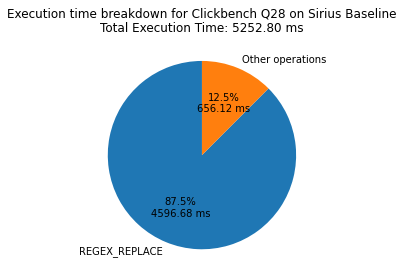

In [29]:
import matplotlib.pyplot as plt

# Data
labels = ["REGEX_REPLACE", "Other operations"]
times_ms = [4596.68, 656.12]
total_time = sum(times_ms)

# Custom autopct function
def autopct_with_time(pct):
    time_ms = pct / 100 * total_time
    return f"{pct:.1f}%\n{time_ms:.2f} ms"

# Create pie chart
plt.figure()
plt.pie(
    times_ms,
    labels=labels,
    autopct=autopct_with_time,
    startangle=90
)
plt.title("Execution time breakdown for Clickbench Q28 on Sirius Baseline\nTotal Execution Time: 5252.80 ms")

plt.tight_layout()
plt.savefig("breakdown_baseline.png", dpi=200)
plt.show()


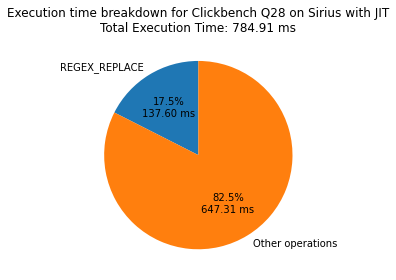

In [30]:
import matplotlib.pyplot as plt

# Data %137.60 ms 784.91 ms  other ops 647.31
labels = ["REGEX_REPLACE", "Other operations"]
times_ms = [137.60, 647.31]
total_time = sum(times_ms)

# Custom autopct function
def autopct_with_time(pct):
    time_ms = pct / 100 * total_time
    return f"{pct:.1f}%\n{time_ms:.2f} ms"

# Create pie chart
plt.figure()
plt.pie(
    times_ms,
    labels=labels,
    autopct=autopct_with_time,
    startangle=90
)
plt.title("Execution time breakdown for Clickbench Q28 on Sirius with JIT\nTotal Execution Time: 784.91 ms")

plt.tight_layout()
plt.savefig("breakdown_with_jit.png", dpi=200)
plt.show()